# Target-Event-Agent Package Guide


## Introduction

The Target-Event-Agent package provides tools for extracting Subject-Verb-Object (SVO) triples from textual data, resolving coreferences, and visualizing the extracted relationships as graphs. It's designed to assist in natural language processing tasks such as information extraction, text analysis, and knowledge graph construction.
Currently, the package only works in English.

<center>
    <img src="https://raw.githubusercontent.com/MassimoStel/TEA_Networks/3cdc2dceaf136c4a802e3dfa5dfd87fc84bccc48/TEA-usageexample.jpg" style="width:560px;height:315px;">
    <p style="font-size:12px; color:gray; margin-top:5px;">
        <sup>1</sup> Example usage of the Agent-did-Target networks framework.
    </p>
</center>

---

## Installation

This package is currently not being featured on *pypi* yet.

As such, this package can only be installed through this Github repository. Note that this requires [Git](https://git-scm.com/) to be installed.


```bash
pip install git+https://github.com/MassimoStel/TEA_Networks.git
```

-----

## How the Package Works
The package processes text to extract SVO triples and builds a graph representing the relationships. Here's a high-level overview:


#### Text Preparation
- Cleaning: Removes unnecessary characters and spaces. Note that we also remove information inside parentheses.
- Coreference Resolution: Replaces pronouns with the nouns they refer to using fastcoref or stanza.

#### SVO Extraction

- Utilizes spaCy for dependency parsing to identify subjects, verbs, and objects.
- Handles various grammatical structures, including compound subjects/objects and passive voice with a custom rule-based approach.
- Data is saved as a pandas dataframe.

#### Graph Construction

- Converts extracted TEA triples into  networkx graphs.
- Nodes represent subjects, verbs, and objects.
- Edges represent the relationships between them, including semantic relations like synonyms.

#### Visualization

- Uses matplotlib to visualize the graph.
- Nodes are color-coded based on Vader sentiment analysis (positive, negative, neutral).
- Edges are styled and colored to represent different types of relationships.

-----

## Usage Guide

#### 1. Importing the Package


First, let's import the necessary functions:


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import teanets as tea

#### 2. Extracting the Target-Event-Agent

After doing so, let's extract the SVOs (Subject-Verb-Object) from a text using the function `extract_svos_from_text`.
This function has the following parameters:
- text (str): The input text to process.
- coref_solver (str, optional): The coreference resolution tool to use ('fastcoref', 'stanza' or `None`). Default is 'fastcoref'.

In [7]:
text = """Gale and Karlach go to a nice pub to drink a tasty beer and a bad wine. They love to share stories with each other. Wyll really loves eggplants and fantastic aubergines."""
svo = tea.extract_svos_from_text(text)

Inference: 100%|██████████| 1/1 [00:00<00:00, 60.20it/s]


This function generates a pandas DataFrame containing the extracted SVO triples and additional metadata:

- Node 1: The first entity in the relationship.
- TEA: The semantic role of Node 1 in the sentence:
    - Agent: Subject
    - Event: Verb
    - Target: Object
- Node 2: The semantic entity in the relationship.
- TEA2: The grammatical role of Node 2, similar to TEA.
- Hypergraph: A hypergraph representing relationships and connections between nodes related to the same verb. Is `N/A` when we have a synonymous relationship.
- Semantic-Syntactic: Indicator of the type of relationship:
    - 0: Syntactic relationship
    - 1: Synonym (Semantic) relationship
- svo_id: Unique identifier for each verb (different for each verb). Is `N/A` when we have a synonymous relationship.

In [3]:
display(svo)

,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,gale,Agent,go,Event,"[[('gale', []), ('karlach', [])], ['go'], [('t...",0,0,0,0
1,karlach,Agent,go,Event,"[[('gale', []), ('karlach', [])], ['go'], [('t...",0,0,0,0
2,go,Event,to nice pub,Target,"[[('gale', []), ('karlach', [])], ['go'], [('t...",0,0,0,0
3,gale,Agent,karlach,Agent,"[[('gale', []), ('karlach', [])], ['go'], [('t...",0,0,0,0
4,gale,Agent,drink,Event,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0
5,karlach,Agent,drink,Event,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0
6,drink,Event,tasty beer,Target,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0
7,drink,Event,bad wine,Target,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0
8,gale,Agent,karlach,Agent,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0
9,tasty beer,Target,bad wine,Target,"[[('gale', []), ('karlach', [])], ['drink'], [...",0,1,0,0


#### 3. Visualizing the SVO Graph

Use the plot_svo_graph function to visualize the relationships. This function has the following parameters:
- df (DataFrame): The DataFrame returned by extract_svos_from_text.
- subject_filter (str, optional): Filter the graph to focus on a specific subject.
- object_filter (str, optional): Filter the graph to focus on a specific object.

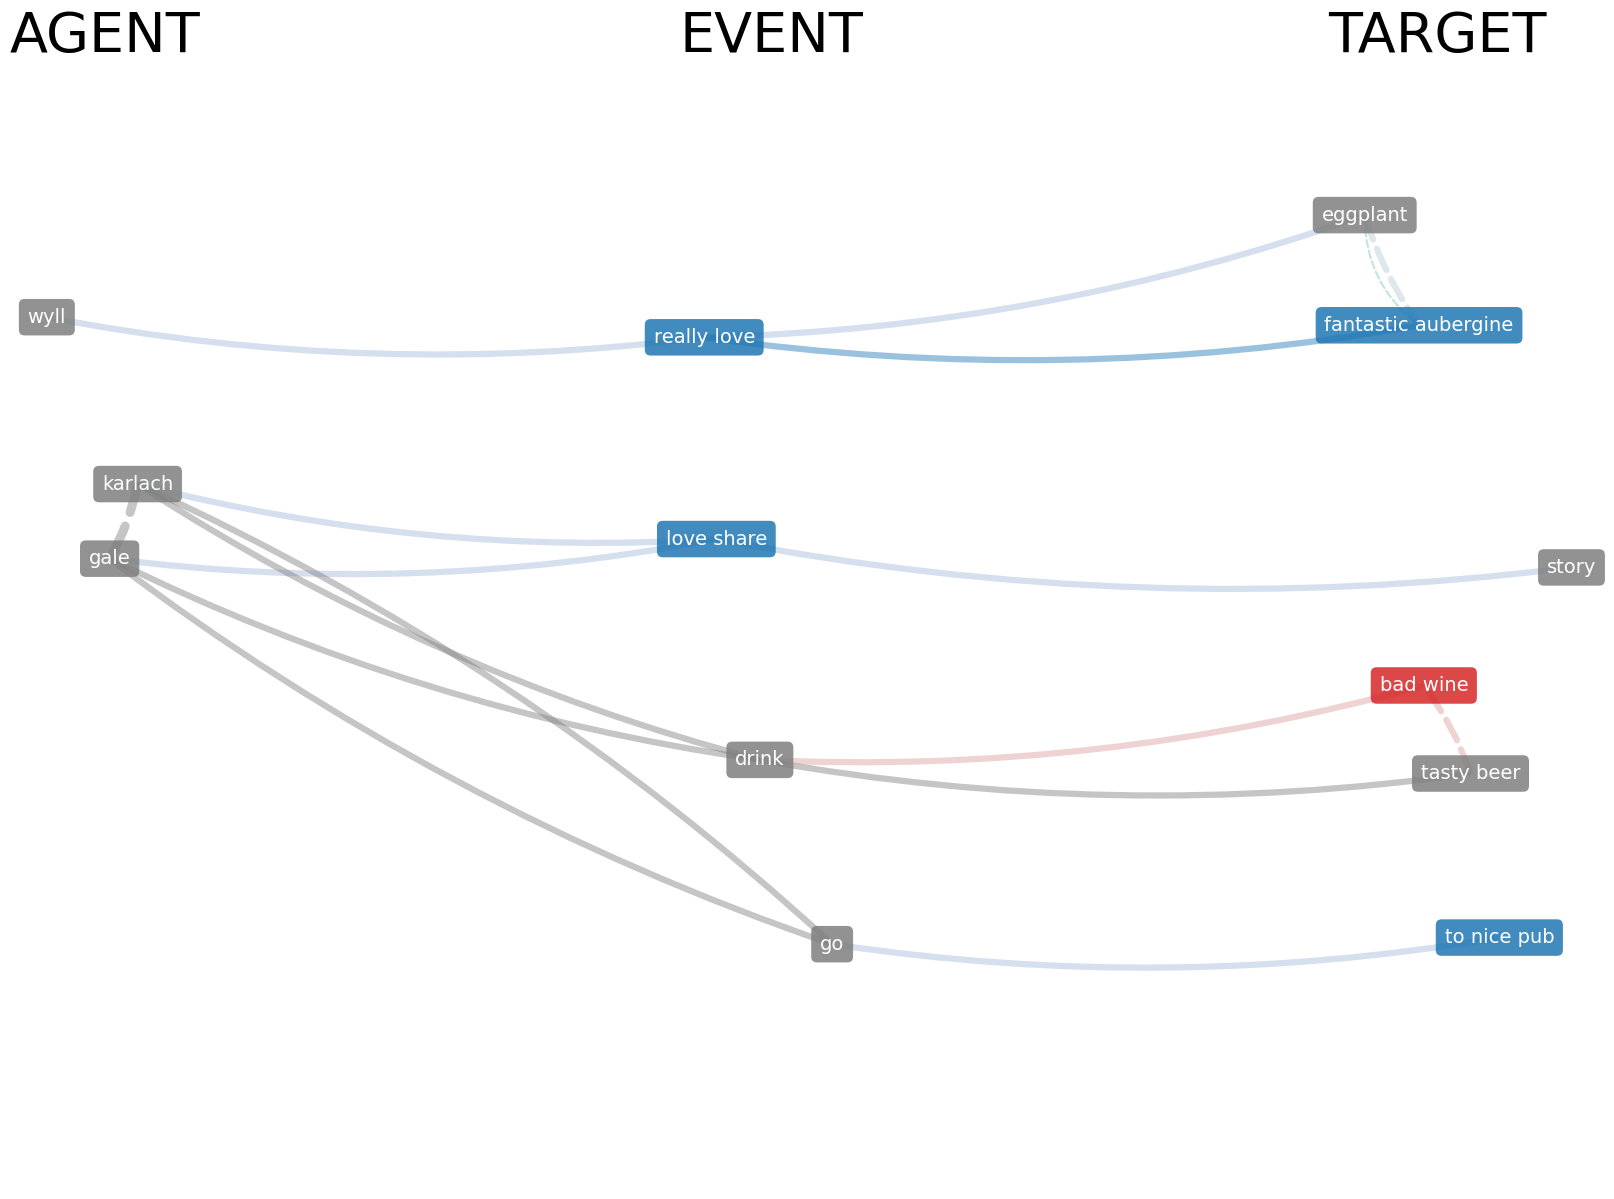

In [4]:
tea.plot_svo_graph(svo)

You can filter the visualization to focus on specific subjects or objects. Notice that this will pick up all subjects that are in the hypergraph where "Gale" is present as a subject.

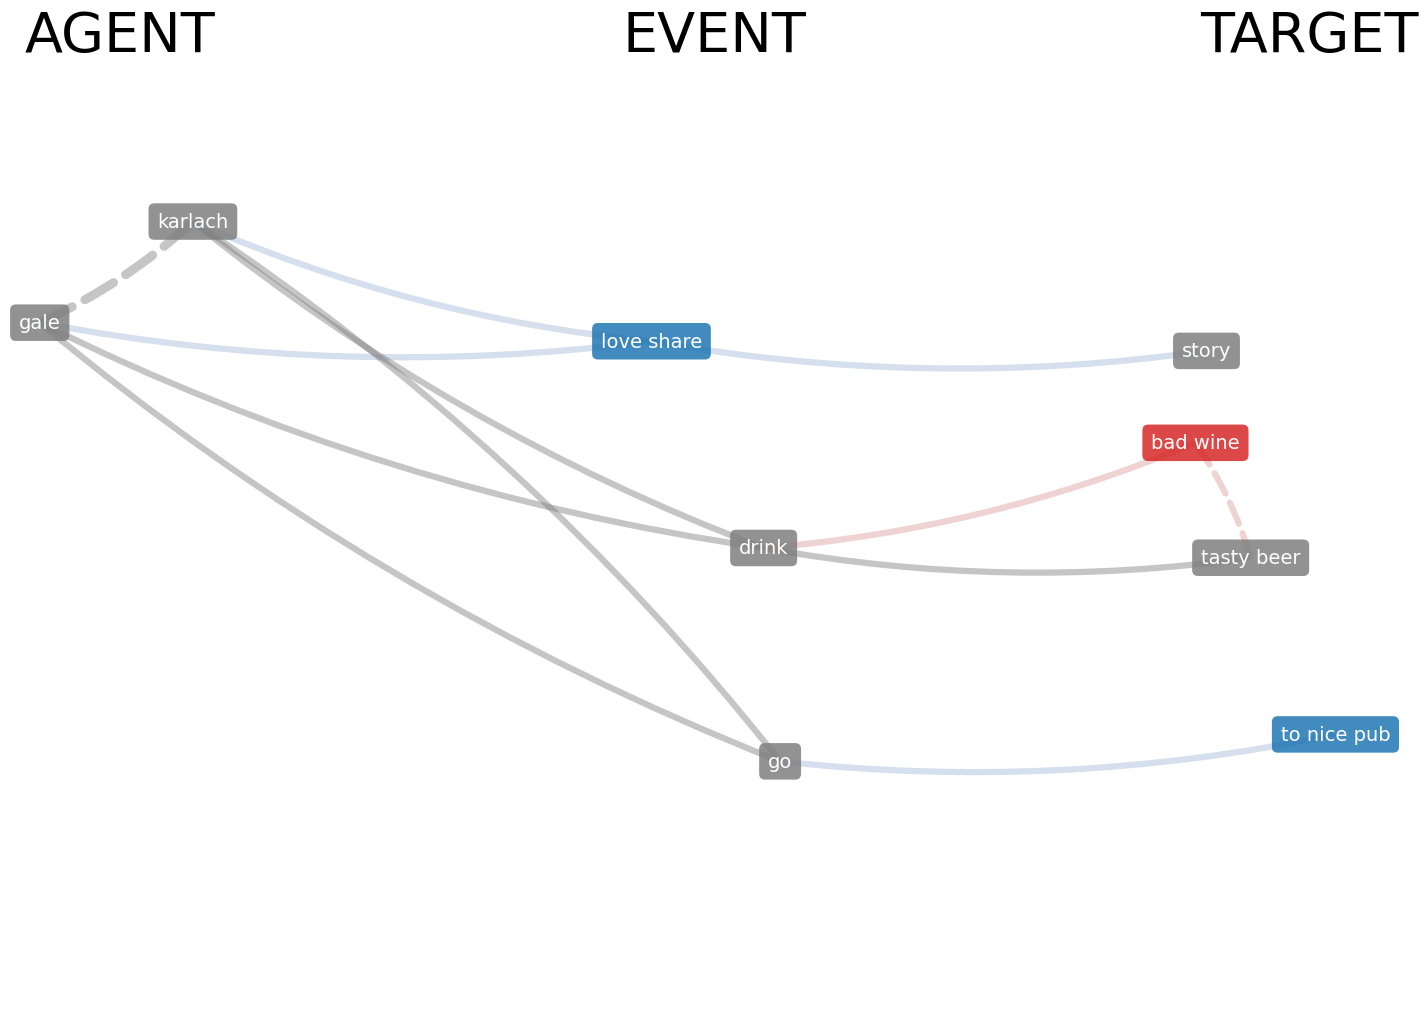

In [5]:
tea.plot_svo_graph(svo, subject_filter='Gale')

Example 2: Text with Coreferences
Coreference resolution replaces "He" with "John".
The graph shows John as the subject performing both actions.

Inference: 100%|██████████| 1/1 [00:00<00:00, 85.93it/s]


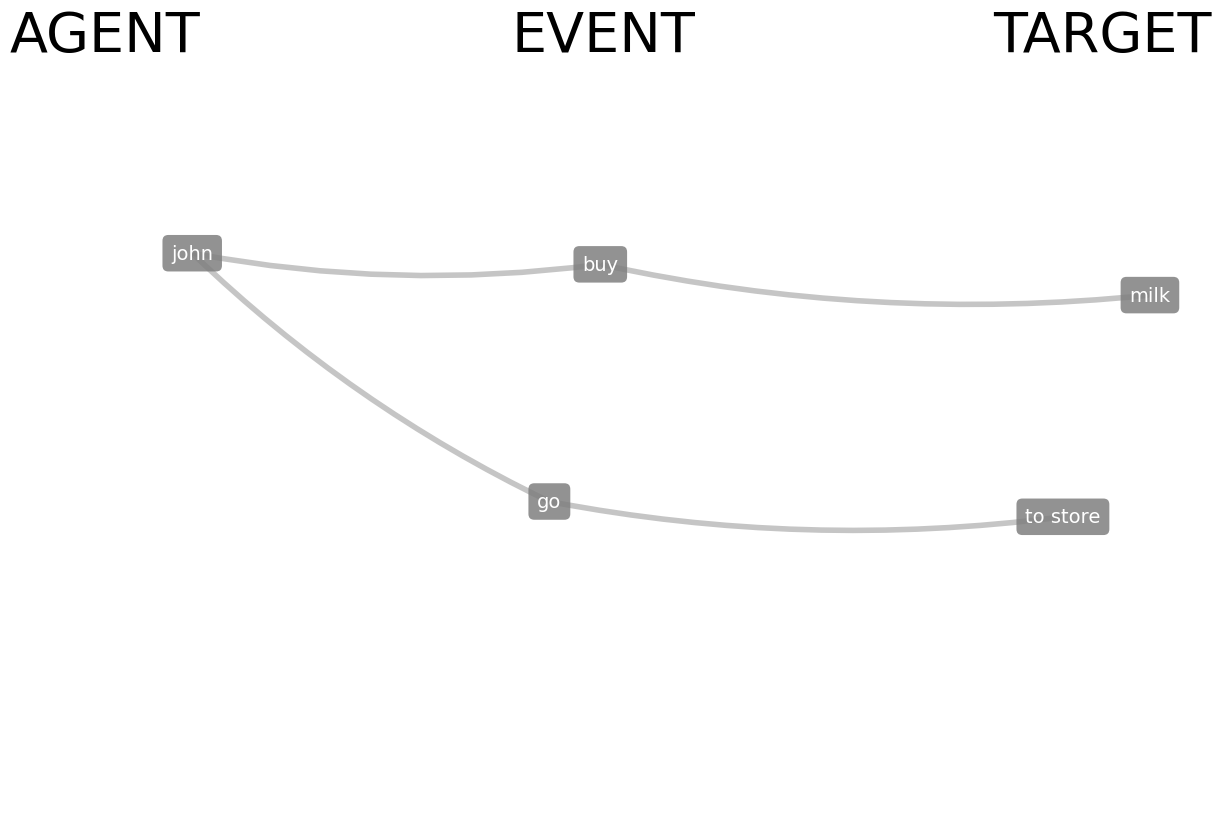

In [6]:
text = "John went to the store. He bought milk."
svos_df = tea.extract_svos_from_text(text)
tea.plot_svo_graph(svos_df)


#### Troubleshooting and Tips
- Performance: Processing large texts may take time due to coreference resolution and parsing.
- Dependencies: Ensure all models and data are properly downloaded to avoid errors.
- Extending Functionality: The code is fairly modular; you can integrate additional NLP tasks as needed.